In [1]:
import numpy as np
np.array([1,2,3]) * 2

array([2, 4, 6])

Vectorization means performing operations on entire datasets without loops.
It makes computations faster and is widely used in AI models.

# Day 4: Pre-processing Techniques

In [1]:
import pandas as pd

data = {
    'Age': [21, None, 23, 24],
    'Score': [80, 75, None, 95]
}

df = pd.DataFrame(data)

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Score'] = df['Score'].fillna(0)

df

,Age,Score
0,21.000000,80.0
1,22.666667,75.0
2,23.000000,0.0
3,24.000000,95.0


Filling missing values with the mean is better than using 0 because 0 can distort the data.
The mean maintains the overall distribution and helps the model learn more accurate patterns.

# Day 5: Linear Regression & Evaluation

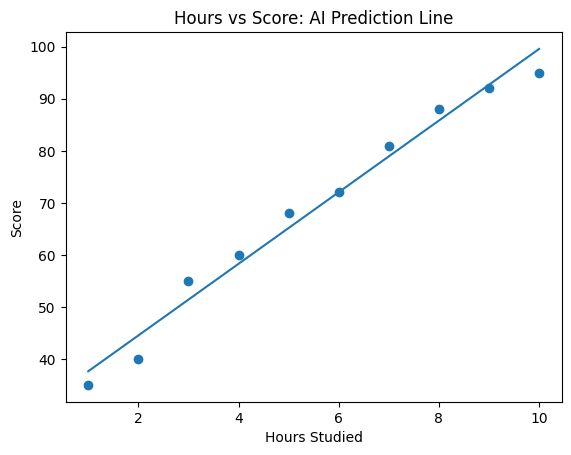

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Score': [35, 40, 55, 60, 68, 72, 81, 88, 92, 95]
}

df = pd.DataFrame(data)

X = df[['Hours']]
y = df['Score']

model = LinearRegression()
model.fit(X, y)

# Plot
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Hours vs Score: AI Prediction Line")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()

If we train the model with only 2 rows of data instead of 8, the model will have less information to learn the pattern. This can lead to inaccurate predictions and poor generalization on new data.

# Day 6: Logistic Regression & Classification Metrics

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Dataset
data = {
    'Hours_Sleep': [8, 7, 6, 5, 8, 4, 9, 5, 6, 4],
    'Coffee_Cups': [1, 2, 2, 4, 0, 5, 1, 4, 3, 6],
    'Passed': [1, 1, 1, 0, 1, 0, 1, 0, 0, 0]
}

df = pd.DataFrame(data)

X = df[['Hours_Sleep', 'Coffee_Cups']]
y = df['Passed']

# Train model
clf = LogisticRegression()
clf.fit(X, y)

# Custom test
manual_input = pd.DataFrame({
    'Hours_Sleep': [3],
    'Coffee_Cups': [7]
})

prediction = clf.predict(manual_input)
print("Prediction for [3 hrs sleep, 7 coffees]:", prediction)

Prediction for [3 hrs sleep, 7 coffees]: [0]


## Reflection

In cancer detection, a False Negative is more dangerous than a False Positive.

A False Negative means the AI fails to detect an actual cancer case, which can delay treatment and seriously affect the patient’s health.

A False Positive may cause temporary stress or extra tests, but it is safer than missing a real disease.

# Day 8: California Housing Project

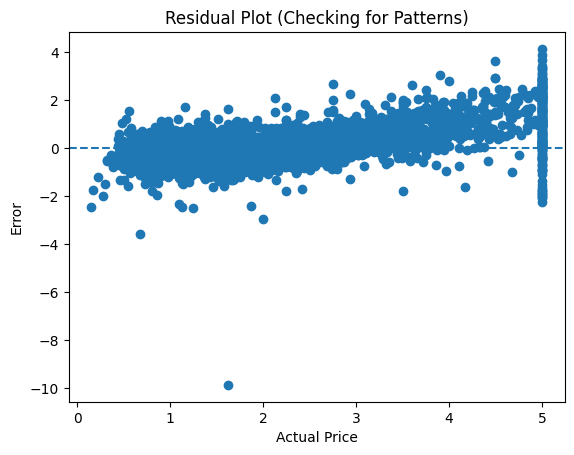

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load data
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Features & target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
predictions = model.predict(X_test_scaled)

# Residuals
residuals = y_test - predictions

# Plot
plt.scatter(y_test, residuals)
plt.axhline(y=0, linestyle='--')

plt.title("Residual Plot (Checking for Patterns)")
plt.xlabel("Actual Price")
plt.ylabel("Error")

plt.show()

If the residual plot shows a U-shape, it means the linear model is not suitable because the relationship between features and target is non-linear. The model is unable to capture the pattern properly.